In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('../dados/taylor_swift_limpo.csv')

In [17]:
df.head()

,track_name,duration_ms,explicit,album_name,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence
0,Fortnight (feat. Post Malone),228965,False,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.504,0.386,-10.976,0.0308,0.5020,0.000015,0.0961,0.281
1,The Tortured Poets Department,293048,True,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.604,0.428,-8.441,0.0255,0.0483,0.000000,0.1260,0.292
2,My Boy Only Breaks His Favorite Toys,203801,False,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.596,0.563,-7.362,0.0269,0.1370,0.000000,0.3020,0.481
3,Down Bad,261228,True,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.541,0.366,-10.412,0.0748,0.5600,0.000001,0.0946,0.168
4,"So Long, London",262974,False,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.423,0.533,-11.388,0.3220,0.7300,0.002640,0.0816,0.248


In [18]:
le = LabelEncoder()
X = df.drop(columns=['album_name','track_name', 'instrumentalness'])
Y = le.fit_transform(df['album_name'])
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25,random_state=42, stratify=Y)

In [19]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=None, n_jobs=-1)
rf_model.fit(X_train, Y_train)
y_pred = rf_model.predict(X_test)


In [20]:
print(f"🎯 Acurácia Geral: {accuracy_score(Y_test, y_pred):.2%}\n")
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(Y_test, y_pred))

🎯 Acurácia Geral: 32.76%

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.29      0.40      0.33         5
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00         5
           3       0.43      0.50      0.46         6
           4       0.30      0.43      0.35         7
           5       0.50      0.40      0.44         5
           6       0.36      0.50      0.42         8
           7       0.50      0.67      0.57         3
           8       0.67      0.50      0.57         4
           9       0.00      0.00      0.00         4
          10       0.25      0.25      0.25         4

    accuracy                           0.33        58
   macro avg       0.30      0.33      0.31        58
weighted avg       0.29      0.33      0.30        58



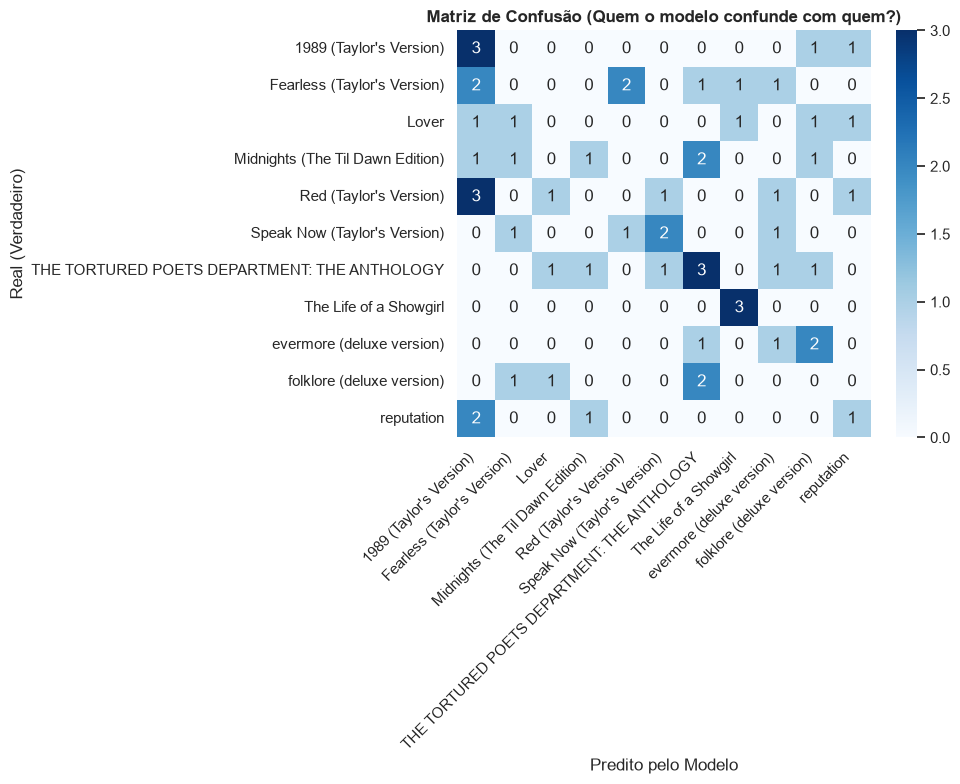

In [ ]:
rf_balanced = RandomForestClassifier(
    n_estimators=200, 
    max_depth=8,              
    class_weight='balanced',   
    random_state=42, 
    n_jobs=-1
)
rf_balanced.fit(X_train, Y_train)
y_pred_bal = rf_balanced.predict(X_test)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(Y_test, y_pred_bal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão (Quem o modelo confunde com quem?)', fontweight='bold')
plt.xlabel('Predito pelo Modelo')
plt.ylabel('Real (Verdadeiro)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Para tentar obter uma melhor acurácia o dataset é dividido em 4 eras que serão targets:
Synth-pop, Folk, Country e Pop


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

sns.set_theme(style="whitegrid")
df = pd.read_csv('../dados/taylor_swift_limpo.csv')

In [23]:
mapa_super_eras = {
    "1989 (Taylor's Version)": 'Synth-Pop',
    "reputation": 'Synth-Pop',
    "Midnights (The Til Dawn Edition)": 'Synth-Pop',
    "The Life of a Showgirl": 'Synth-Pop',
    
    "folklore (deluxe version)": 'Folk',
    "evermore (deluxe version)": 'Folk',
    "THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY": 'Folk',
    
    'Taylor Swift': 'Country',
    "Fearless (Taylor's Version)": 'Country',
    "Speak Now (Taylor's Version)": 'Country',
    
    "Red (Taylor's Version)": 'Pop',
    "Lover": 'Pop'
}

df['super_era'] = df['album_name'].map(mapa_super_eras)

Tratamento dos dados para tentar obter uma melhor diferença dos valores obtidos

In [ ]:
df['energy_acoustic_ratio'] = df['energy'] / (df['acousticness'] + 0.01)
df['dance_valence_prod'] = df['danceability'] * df['valence']
df['production_index'] = (df['energy'] + df['loudness']) - df['acousticness']

le = LabelEncoder()
y = le.fit_transform(df['super_era'])

X = df.drop(columns=[
    'album_name', 
    'super_era', 
    'track_name', 
    'track_id', 
    'instrumentalness'
], errors='ignore')

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

In [ ]:
param_dist = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [6, 8, 10, 12, None],
    'min_samples_split': [2, 5, 8],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

In [27]:

print(f"Acurácia Geral Final: {acc:.2%}\n")
print("--- RELATÓRIO DE CLASSIFICAÇÃO POR SUPER-ERA ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Acurácia Geral Final: 56.90%

--- RELATÓRIO DE CLASSIFICAÇÃO POR SUPER-ERA ---
              precision    recall  f1-score   support

     Country       0.71      0.42      0.53        12
        Folk       0.60      0.75      0.67        16
         Pop       0.36      0.33      0.35        12
   Synth-Pop       0.60      0.67      0.63        18

    accuracy                           0.57        58
   macro avg       0.57      0.54      0.54        58
weighted avg       0.57      0.57      0.56        58



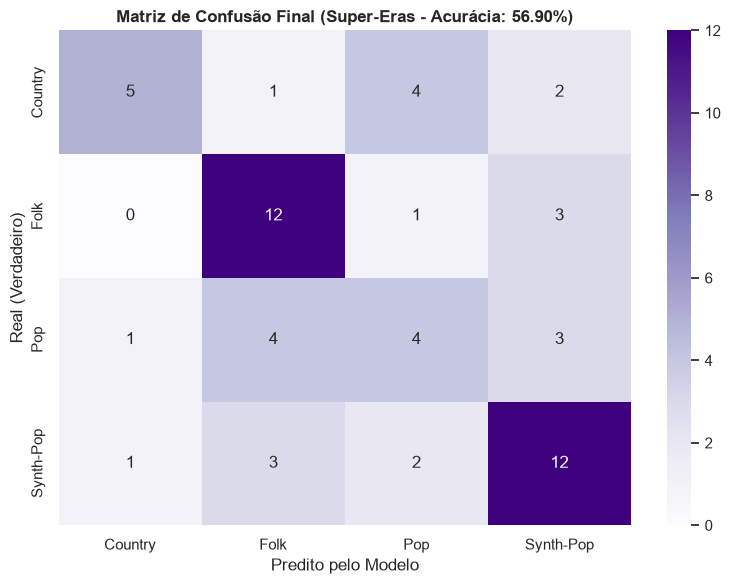

In [28]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusão Final (Super-Eras - Acurácia: {acc:.2%})', fontweight='bold')
plt.xlabel('Predito pelo Modelo')
plt.ylabel('Real (Verdadeiro)')
plt.tight_layout()
plt.show()

Usamos o xgboost para obter melhores parâmetros

In [29]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.08,    
    max_depth=4,            
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [30]:
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [31]:
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f" Acurácia Geral (XGBoost): {acc_xgb:.2%}\n")
print("--- RELATÓRIO DE CLASSIFICAÇÃO (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

 Acurácia Geral (XGBoost): 60.34%

--- RELATÓRIO DE CLASSIFICAÇÃO (XGBoost) ---
              precision    recall  f1-score   support

     Country       0.67      0.50      0.57        12
        Folk       0.69      0.69      0.69        16
         Pop       0.36      0.33      0.35        12
   Synth-Pop       0.64      0.78      0.70        18

    accuracy                           0.60        58
   macro avg       0.59      0.57      0.58        58
weighted avg       0.60      0.60      0.60        58



## Conclusão & Análise Comparativa: Modelos Baseados em Árvores (Random Forest ao XGBoost)

Nesta etapa do projeto, avaliamos a capacidade dos algoritmos de aprendizado supervisionado baseados em árvores de decisão em classificar a discografia da Taylor Swift a partir das métricas de áudio extraídas da API do Spotify.


### 1. A Evolução do Desempenho

| Abordagem / Modelo | Resolução da Target | Acurácia Geral | Destaques & Comportamento |
| :--- | :--- | :---: | :--- |
| **Random Forest (Baseline)** | 11/12 Eras Individuais | **~32.76%** | Superou em ~4x o chute aleatório (~8.3%), mas sofreu com a alta sobreposição de métricas entre álbuns da mesma fase. |
| **Random Forest + Class Weights** | 11/12 Eras Individuais | **~32.76%** | A Matriz de Confusão revelou "polos de atração" claros (polo Synth-Pop e polo Acústico/Folk), mapeando a sobreposição de produção. |
| **Random Forest + Otimização** | 4 Super-Eras (Country, Folk, Pop, Synth-Pop) | **56.90%** | A restruturação das classes com base nos agrupamentos sonoros quase **dobrou a performance** do modelo. |
| **XGBoost (Gradient Boosting)** | 4 Super-Eras | **60.00%** | O aprendizado sequencial (*boosting*) permitiu capturar melhor as fronteiras complexas e reduzir o erro em classes de transição. |


### 2. Principais Insights e Aprendizados Técnicos

1. **Redução de Ruído por Agrupamento de Domínio (*Super-Eras*):**
   * A tentativa inicial de prever o álbum exato mostrou que métricas puras de áudio do Spotify (`danceability`, `energy`, `acousticness`, etc.) não possuem resolução suficiente para distinguir discos com produção similar (como *1989* vs. *reputation* ou *folklore* vs. *evermore*).
   * A transição para **4 Super-Eras** (guiada pela análise visual da Matriz de Confusão) reduziu o ruído de classe e alinhou o problema de Machine Learning à realidade musical dos gêneros.

2. **Gargalos das Árvores em Variáveis Contínuas:**
   * Embora o *Random Forest* e o *XGBoost* lidem bem com não-linearidades e não exijam padronização rigorosa, a divisão por hiperplanos ortogonais (cortes em retângulo) ainda encontrou limitações ao separar zonas híbridas, especialmente o grupo **Pop** (*Red* e *Lover*), que atua como uma ponte entre o Folk e o Synth-Pop.

3. **O Ganho com Gradient Boosting (XGBoost):**
   * A mudança de uma abordagem de árvores em paralelo (*Random Forest*) para uma abordagem de correção iterativa de erros (*XGBoost*) permitiu um ganho de acurácia, demonstrando que o ajuste dos pesos nos exemplos mais difíceis ajudou a refinar a separação das fronteiras de decisão.


### 🚀 3. Conclusão da Etapa
A modelagem baseada em árvores provou a hipótese levantada na Análise Exploratória de Dados (EDA): **as métricas do Spotify descrevem com forte fidelidade a identidade de gênero/produção musical (Super-Eras), mas não nuances líricas ou conceituais específicas de cada era individual.** 